In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.5236074519707


In [95]:
logM_names = ["logMmax11", "logM11-11.5", "logM11.5-12", "logM12-12.5", "logM12.5-13", "logMmin13"]



In [35]:
logM_names = ["logMmin13.5"]

In [96]:
object2shuffle = "gal"
interp="tsc"
Pk_shuffled_list_logMs = []

for logM_name in logM_names:
    Pk_shuffled_list = []
    names_list = []
    seed_i = 0
    seed_f = 100
    n_seed = seed_f - seed_i

    power_list = []
    mean_intensities = []
    odir = "ps_data"
    snapnum=40

    for seed in range(seed_i,seed_f):
        fname = f"{odir}/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_{object2shuffle}/{logM_name}/seed{seed}.pickle"
        
        if seed == 0:
            print(fname)
        with open(fname, "rb") as f:
            Pk_mean_gal_shuffled = pickle.load(f)
            #print("mean", Pk_mean_cent_shuffled)
            Pk_gal_shuffled = pickle.load(f)
            #print(Pk_mean_gal_shuffled)
            power_list.append(Pk_gal_shuffled["power"].real)

            mean_intensities.append(Pk_mean_gal_shuffled)

            print("shotnoise", Pk_gal_shuffled.attrs["shotnoise"])
            Pk_shuffled_list.append(Pk_gal_shuffled)
            names_list.append(f"seed{seed}")


    power_arr = np.array(power_list)
    Pk_shuffled_list_logMs.append(Pk_shuffled_list)

ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_gal/logMmax11/seed0.pickle
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
s

In [30]:
importlib.reload(ps)

<module 'MyHaloPS' from '/cosma/home/dp004/dc-zhan5/MyHaloPS.py'>

is list
shotnoise:  130.52360745197058
shotnoise:  130.5236074519707
0


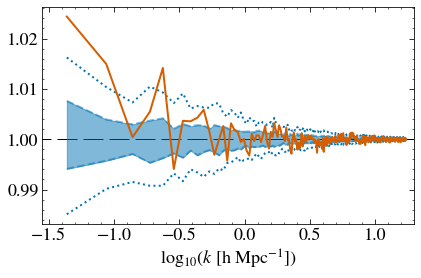

In [38]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list_logMs[0]], percentiles=[25, 5], labels=["Centrals", "Satellites" ], ratio_ylabel_list=["Random",""], return_color_leg=True, remove_ylabel=True)
   

is list
shotnoise:  130.52360745197072
shotnoise:  130.5236074519707
0


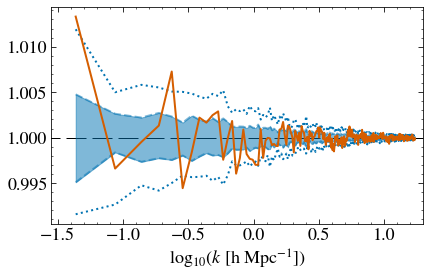

In [34]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list_logMs[0]], percentiles=[25, 5], labels=["Centrals", "Satellites" ], ratio_ylabel_list=["Random",""], return_color_leg=True, remove_ylabel=True)
   

In [7]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

is list
shotnoise:  130.52360745197055
shotnoise:  130.5236074519707


AttributeError: 'numpy.ndarray' object has no attribute 'plot'

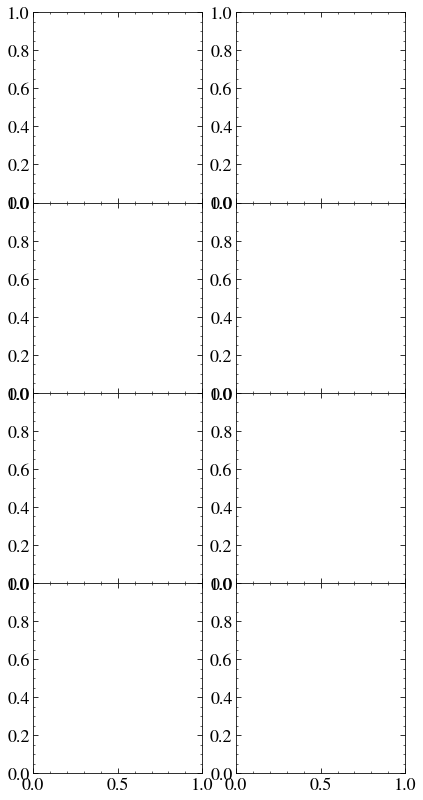

In [46]:

fig, axs = plt.subplots(8, 1, sharex=True, gridspec_kw={'hspace': 0}, figsize=(2*10/3, 14))
for i, logM_name in enumerate(logM_names):
    color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list_logMs[i]], percentiles=[25, 5], labels=["Centrals", "Satellites" ], ratio_ylabel_list=["Random",""], create_fig=False, ax=axs[i], return_color_leg=True, remove_ylabel=True)
    #axs[i].set_ylim(0.95,1.07)
    axs[i].set_ylim(0.955,1.07)
    if i == 0:
        logM_name = "logM < 11"
    if i == 7:
        logM_name = "logM > 13.8"
    axs[i].annotate(f"{logM_name}", (0.4,1.03)) 
#axs[-1].annotate(r"$P(k)/\bar{P}(k)_{\rm Shuffled}$", (0, 0.55), xycoords='figure fraction', rotation=90, fontsize=18, va="center")

fig.legend(handles=color_leg[1:], labels=[r"$P(k)_{\rmTNG}/\bar{P}(k)_{\rmShuffled}$"], loc='upper left', bbox_to_anchor=(0.15, 0.875))
dot_line = Line2D([],[],color=palette_tab10[0], linestyle="dotted")
fig.legend(handles=[dot_line], labels=[r"5 - 95% $(P(k)_{\rm Shuffled}/\bar{P}(k)_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.15, 0.82))

axs[3].set_ylabel(r"$P(k)/\bar{P}(k)_{\rm Shuffled}$")

#plt.legend()
#plt.savefig("figures/shuffled_ps_logMs.pdf", format="pdf", bbox_inches="tight")

is list
shotnoise:  130.52360745197055
shotnoise:  130.5236074519707
0
is list
shotnoise:  130.52360745197066
shotnoise:  130.5236074519707
0
is list
shotnoise:  130.52360745197072
shotnoise:  130.5236074519707
0
is list
shotnoise:  130.52360745197075
shotnoise:  130.5236074519707
0
is list
shotnoise:  130.52360745197058
shotnoise:  130.5236074519707
0
is list
shotnoise:  130.52360745197072
shotnoise:  130.5236074519707
0


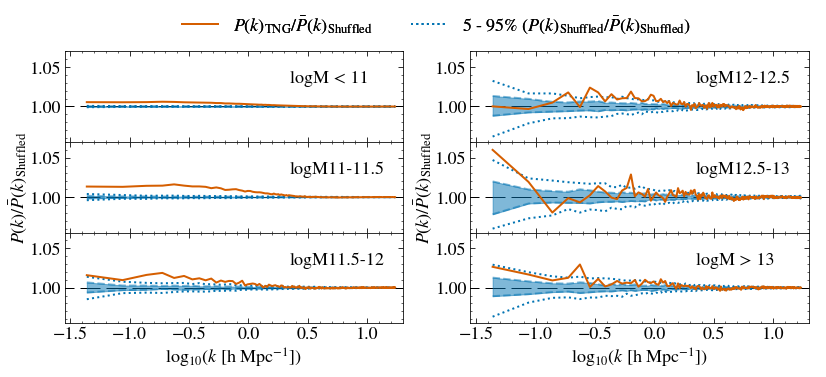

In [104]:

fig, axs = plt.subplots(3, 2, sharex=True, gridspec_kw={'hspace': 0}, figsize=(4*10/3, 5))
for i, logM_name in enumerate(logM_names):
    color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list_logMs[i]], percentiles=[25, 5], labels=["Centrals", "Satellites" ], ratio_ylabel_list=["Random",""], create_fig=False, ax=axs[i%3][i//3], return_color_leg=True, remove_ylabel=True)
    #axs[i].set_ylim(0.95,1.07)
    axs[i%3][i//3].set_ylim(0.955,1.07)
    if i == 0:
        logM_name = "logM < 11"
    if i == 5:
        logM_name = "logM > 13"
    axs[i%3][i//3].annotate(f"{logM_name}", (0.35,1.03)) 
#axs[-1].annotate(r"$P(k)/\bar{P}(k)_{\rm Shuffled}$", (0, 0.55), xycoords='figure fraction', rotation=90, fontsize=18, va="center")

leg = axs[0][0].legend(handles=color_leg[1:], labels=[r"$P(k)_{\rmTNG}/\bar{P}(k)_{\rmShuffled}$"], loc='lower left', bbox_to_anchor=(0.3, 1))
axs[0][0].add_artist(leg)
dot_line = Line2D([],[],color=palette_tab10[0], linestyle="dotted")
leg = axs[0][1].legend(handles=[dot_line], labels=[r"5 - 95% $(P(k)_{\rm Shuffled}/\bar{P}(k)_{\rm Shuffled})$"], loc='lower right', bbox_to_anchor=(0.7, 1))
axs[0][1].add_artist(leg)
#axs[1][1].set_ylabel(r"$P(k)/\bar{P}(k)_{\rm Shuffled}$")
x0 = min([ax.get_position().x0 for ax in axs[:,0]])
y0 = min([ax.get_position().y0 for ax in axs[:,0]])
x1 = max([ax.get_position().x1 for ax in axs[:,0]])
y1 = max([ax.get_position().y1 for ax in axs[:,0]])

# Hidden axes for common x and y labels
plt.axes([x0, y0, x1 - x0, y1 - y0], frameon=False)
plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False, which="both")
plt.ylabel(r"$P(k)/\bar{P}(k)_{\rm Shuffled}$", labelpad=10)

x0 = min([ax.get_position().x0 for ax in axs[:,1]])
y0 = min([ax.get_position().y0 for ax in axs[:,1]])
x1 = max([ax.get_position().x1 for ax in axs[:,1]])
y1 = max([ax.get_position().y1 for ax in axs[:,1]])

# Hidden axes for common x and y labels
plt.axes([x0, y0, x1 - x0, y1 - y0], frameon=False)
plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False, which="both")

# Labelize

plt.ylabel(r"$P(k)/\bar{P}(k)_{\rm Shuffled}$", labelpad=10)
#plt.legend()
#plt.savefig("figures/shuffled_ps_logMs.pdf", format="pdf", bbox_inches="tight")